In [ ]:
from mpl_toolkits.axes_grid1 import Divider, Size
import matplotlib.pyplot as plt

def fixed_axes(ax_w=9, ax_h=7, margins=(1.2, 1.2, 1.2, 0.6)):  
    """
    Crea una figura con assi di dimensione fissa in pollici.
    margins = (left, right, bottom, top) in pollici.
    """
    # dimensioni totali figura = area assi + margini
    fig_w = ax_w + margins[0] + margins[1]
    fig_h = ax_h + margins[2] + margins[3]

    fig = plt.figure(figsize=(fig_w, fig_h))
    divider = Divider(
        fig, (0, 0, 1, 1),
        horizontal=[Size.Fixed(margins[0]), Size.Fixed(ax_w), Size.Fixed(margins[1])],
        vertical=[Size.Fixed(margins[2]), Size.Fixed(ax_h), Size.Fixed(margins[3])]
    )

    ax = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=1, ny=1))
    return fig, ax


import re

def query_to_tag(query: str,key_map = {
        's': "s",
        "burstiness": "b",
    }) -> str:
    parts = re.findall(r'(\w+)\s*==\s*([\w.]+)', query)
    if not parts:
        return ""

    

    out = []
    for k, v in parts:
        out.append(f"{key_map.get(k, k)}={v}")

    return "__".join(out)

In [2]:
import pickle
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
from pathlib import Path
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import Divider, Size
from itertools import product
from string import ascii_lowercase
from matplotlib.lines import Line2D



from IPython.display import display, clear_output

from stats_utils import kde_scatter_estimate,KDEScatterData, plot_scatter_from_kde

In [3]:
mpl.rcdefaults()

N = 2
#* BIGGER SIZE
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = 'STIXGeneral'
plt.rc('font', size=22)          # controls default text sizes
plt.rc('axes', titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=22)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=22)    # fontsize of the tick labels
plt.rc('ytick', labelsize=22)    # fontsize of the tick labels
plt.rc('legend', fontsize=22)    # legend fontsize
plt.rc('figure', titlesize=14)   # fontsize of the figure title


In [4]:
from pathlib import Path

In [5]:
BATCH = "008"
# Use .expanduser() to turn "~" into "/home/yourusername"
PARQUETS = Path("~/tesi/sarafu/final_simulations").expanduser()
PICKLED = Path("~/papers/adtxns_paper/pickled_data").expanduser()
SARAFU_PICKLED = PICKLED / "sarafu"

FIGURES = Path("~/papers/adtxns_paper/figures/histograms").expanduser()


In [6]:
sarafu = pickle.load(open(SARAFU_PICKLED / "sarafu.pkl", "rb"))

In [7]:
metadata = pickle.load(open(PICKLED / BATCH / "metadata.pkl", "rb"))


SINGLE SIMULATION (SELECT COUPLE s and burstiness)

In [10]:
burstiness = 0.75
spending_noise = 1
QUERY = f"s == {spending_noise} and burstiness == {burstiness}"

In [9]:
simu_id = metadata.query(QUERY).iloc[0].simulation_id
meta_row = metadata.query(QUERY).iloc[0]

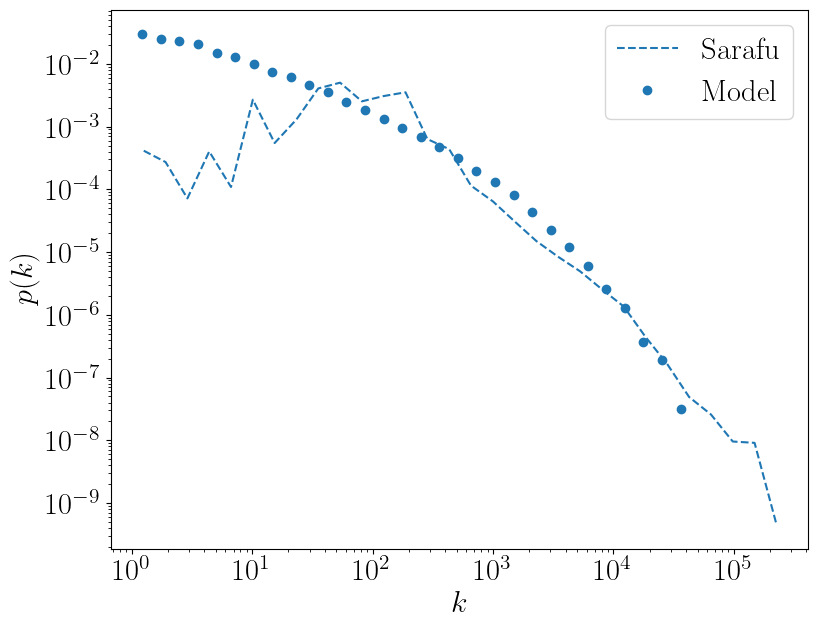

In [35]:
keyword = "final_balances"
disp = "single"


# filenames (standard)
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
fname_simu   = f"simulation__metric={keyword}__s={spending_noise}__b={burstiness}"

# load
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))
h2 = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

# plot
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

ax.plot(h1[0], h1[1], "--", label="Sarafu", color="tab:blue")
ax.plot(h2[0], h2[1], "o",  label=rf"Model",  color="tab:blue")

ax.set_xlabel("$k$")
ax.set_ylabel("$p(k)$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()

# save figure with same stem
# fig.savefig(FIGURES / f"{fname_simu}.pdf")


fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__s={spending_noise}__b={burstiness}.pdf"
)

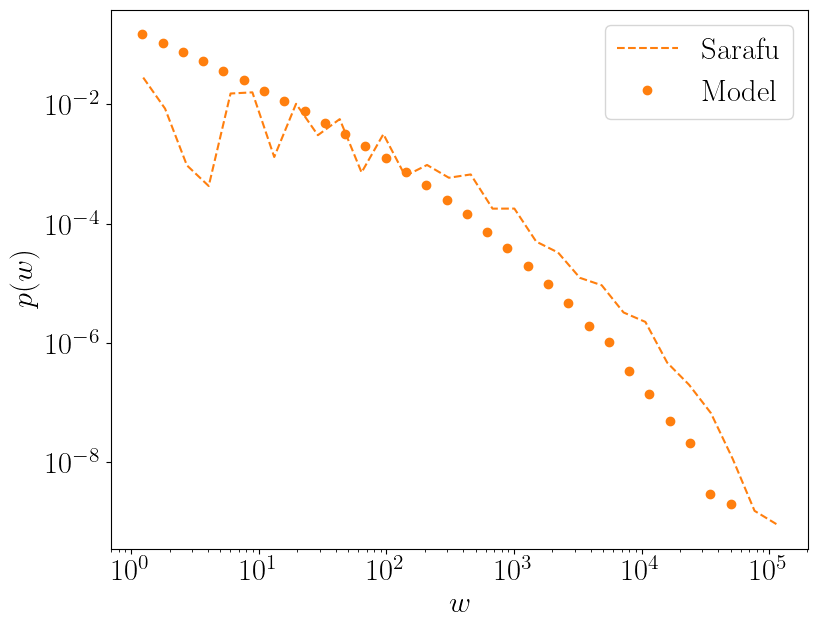

In [36]:
keyword = "transaction_size"
disp = "single"


# filenames (standard)
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
fname_simu   = f"simulation__metric={keyword}__s={spending_noise}__b={burstiness}"

# load
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))
h2 = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

# plot
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

ax.plot(h1[0], h1[1], "--", label="Sarafu", color="tab:orange")
ax.plot(h2[0], h2[1], "o",  label=rf"Model", color="tab:orange")

ax.set_xlabel("$w$")
ax.set_ylabel("$p(w)$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()

fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__s={spending_noise}__b={burstiness}.pdf"
)


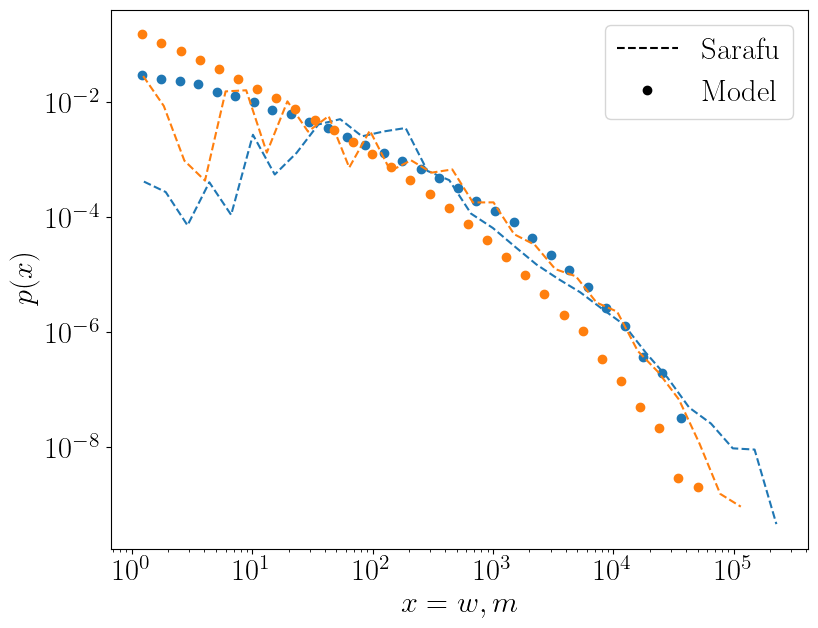

In [38]:
# keywords
kw_fb = "final_balances"
kw_ts = "transaction_size"

disp = 'overlap'

keyword = kw_fb + "+"+ kw_ts

# filenames (standard)
fname_fb_sarafu = f"sarafu__metric={kw_fb}__s=NA__b=NA"
fname_fb_simu   = f"simulation__metric={kw_fb}__s={spending_noise}__b={burstiness}"

fname_ts_sarafu = f"sarafu__metric={kw_ts}__s=NA__b=NA"
fname_ts_simu   = f"simulation__metric={kw_ts}__s={spending_noise}__b={burstiness}"

# load histograms
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_fb_sarafu}.pkl", "rb"))
h2 = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_fb_simu}.pkl", "rb"))

h3 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_ts_sarafu}.pkl", "rb"))
h4 = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_ts_simu}.pkl", "rb"))

# plot
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

ax.plot(h1[0], h1[1], "--", color="tab:blue")
ax.plot(h2[0], h2[1], "o",  color="tab:blue")

ax.plot(h3[0], h3[1], "--", color="tab:orange")
ax.plot(h4[0], h4[1], "o",  color="tab:orange")

ax.set_xlabel("$x = w, m$")
ax.set_ylabel("$p(x)$")
ax.set_xscale("log")
ax.set_yscale("log")

# label_model=rf"Model: $\xi={s}, b={b}$"
label_model=rf"Model"

# custom legend
legend_elements = [
    Line2D([0], [0], linestyle="--", color="black", label="Sarafu"),
    Line2D([0], [0], linestyle="None", marker="o", color="black",
           label=label_model),
    # Line2D([0], [0], linestyle="-", color="C0", label="Final Balances"),
    # Line2D([0], [0], linestyle="-", color="C1", label="Transaction Sizes"),
]

ax.legend(handles=legend_elements)

# save
fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__s={spending_noise}__b={burstiness}.pdf"
)

VARYING THE SIMULATION (SELECT JUST burstiness or s)

In [8]:
burstiness = 0.75
QUERY = f"burstiness == {burstiness}"
meta_slice = metadata.query(QUERY)
meta_slice = meta_slice.query("s not in [20,100]")
tag=query_to_tag(QUERY)


# meta_slice

In [9]:
tag

'b=0.75'

In [50]:
#* SAFE NORMAL * THI SCRIPT WORKS WELL, GEENRATES GOOD QUALITY FIGURES
mpl.rcdefaults()
N=0
#* BIGGER SIZE
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = 'STIXGeneral'
plt.rc('font', size=N+22)          # controls default text sizes
plt.rc('axes', titlesize=N+24)     # fontsize of the axes title
plt.rc('axes', labelsize=N+24)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('ytick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('legend', fontsize=N+22)    # legend fontsize
plt.rc('figure', titlesize=N+24)   # fontsize of the figure title

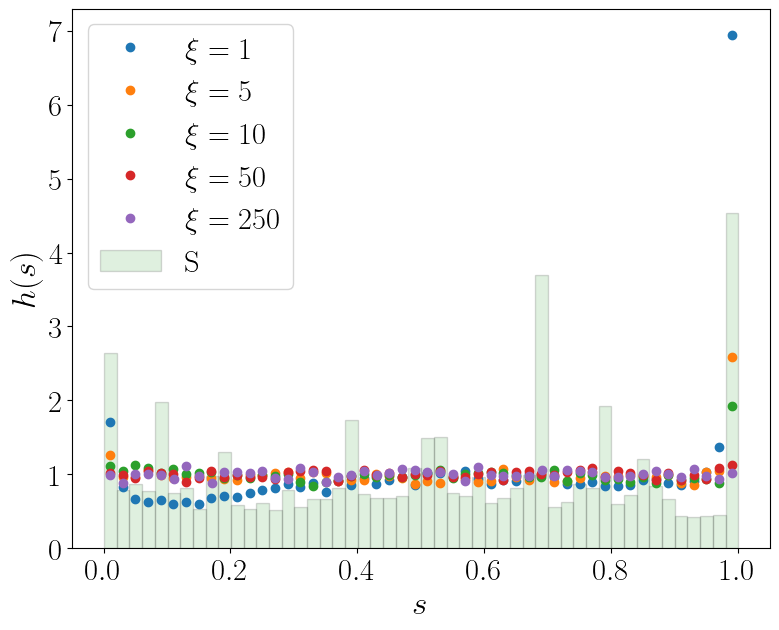

In [ ]:

keyword = "spending_parameters"

# ---- load sarafu (bar base) ----
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))

fig, ax = plt.subplots(1, 1, figsize=(9, 7))

# sarafu as bars (expects h1 = (centers, heights, widths))
ax.bar(h1[0], h1[1], h1[2], align="center", edgecolor="k", alpha=0.15, color="tab:green", label='Sarafu')

# ---- overlay simulations (subset selected by QUERY) ----
for _, row in meta_slice.iterrows():
    s = row["s"]
    b = row["burstiness"]

    fname_simu = f"simulation__metric={keyword}__s={s}__b={b}"
    h_simu = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

    # simulation as line (expects h_simu = (x, y) or (centers, heights, ...))
    ax.plot(h_simu[0], h_simu[1], 'o',linestyle="None", label=rf"$\xi={s}$")

ax.set_xlabel(r"$s$")
ax.set_ylabel(r"$h(s)$")
ax.legend()

# optional save (encodes the filter used + metric)
fig.savefig(FIGURES / f"comparison__metric={keyword}__filter={tag}.pdf")


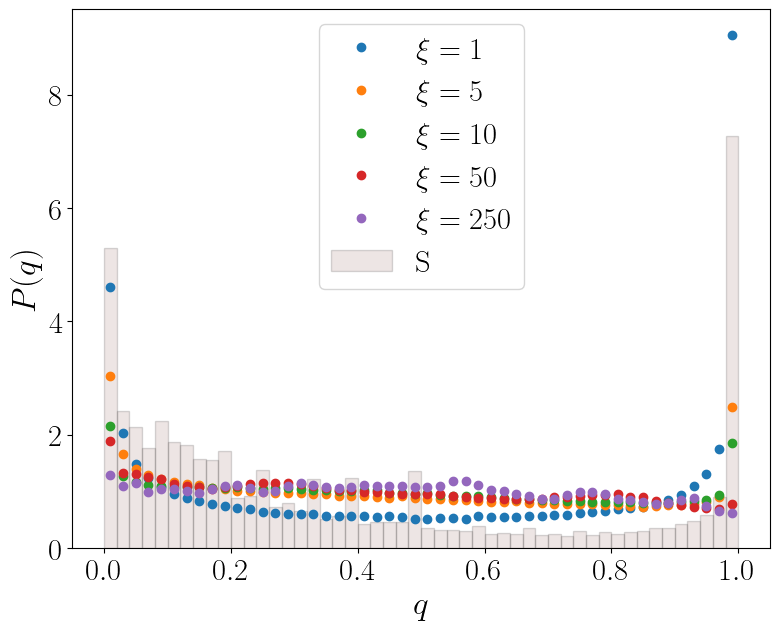

In [ ]:

keyword = "spending_fraction"

# ---- load sarafu (bar base) ----
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))

fig, ax = plt.subplots(1, 1, figsize=(9, 7))

# sarafu as bars (expects h1 = (centers, heights, widths))
ax.bar(h1[0], h1[1], h1[2], align="center", edgecolor="k", alpha=0.15, color="tab:brown", label='Sarafu')

# ---- overlay simulations (subset selected by QUERY) ----
for _, row in meta_slice.iterrows():
    s = row["s"]
    b = row["burstiness"]

    fname_simu = f"simulation__metric={keyword}__s={s}__b={b}"
    h_simu = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

    # simulation as line (expects h_simu = (x, y) or (centers, heights, ...))
    ax.plot(h_simu[0], h_simu[1], 'o',linestyle="None", label=rf"$\xi={s}$")

ax.set_xlabel(r"$q$")
ax.set_ylabel(r"$P(q)$")

ax.legend()

# optional save (encodes the filter used + metric)
fig.savefig(FIGURES / f"comparison__metric={keyword}__filter={tag}.pdf")


In [ ]:
# keyword = "in_degree"
# xlabel = r"$k_{in}$"
# ylabel = r"$P(k_{in})$"
# disp = "overlap"
# loglog = True
# tag = query_to_tag(QUERY)

# # ---- load sarafu (bar base) ----
# fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
# h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))

# # # --------------------------------------------------
# # # FIXED AXES GEOMETRY (edit numbers if needed)
# # # --------------------------------------------------
# # ax_w, ax_h = 9, 7                 # axes size in inches
# # left, right = 1.0, 1.5            # margins in inches
# # bottom, top = 1.2, 0.6            # margins in inches

# # fig_w = ax_w + left + right
# # fig_h = ax_h + bottom + top

# fig, ax = plt.subplots(1, 1, figsize=(9, 7))

# # sarafu as bars (expects h1 = (centers, heights, widths))
# # ax.bar(h1[0], h1[1], h1[2], align="center", edgecolor="k", alpha=0.15, color="tab:brown", label='Sarafu')
# ax.plot(h1[0],h1[1],'k--',marker = None)
# # ---- overlay simulations (subset selected by QUERY) ----
# for _, row in meta_slice.iterrows():
#     s = row["s"]
#     b = row["burstiness"]

#     fname_simu = f"simulation__metric={keyword}__s={s}__b={b}"
#     h_simu = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

#     # simulation as line (expects h_simu = (x, y) or (centers, heights, ...))
#     ax.plot(h_simu[0], h_simu[1], 'o',linestyle="None", label=rf"$\xi={s}$")

# ax.set_xlabel(xlabel)
# ax.set_ylabel(ylabel)
# if loglog:
#     ax.loglog()

# ax.legend()

# # optional save (encodes the filter used + metric)
# # print(FIGURES / f"{disp}__metric={keyword}__filter={tag}.pdf")
# fig.savefig(FIGURES / f"{disp}__metric={keyword}__filter={tag}.pdf")


In [57]:
burstiness = 0.75
QUERY = f"burstiness == {burstiness}"
meta_slice = metadata.query(QUERY)
meta_slice = meta_slice.query("s not in [20,100]")
tag=query_to_tag(QUERY)

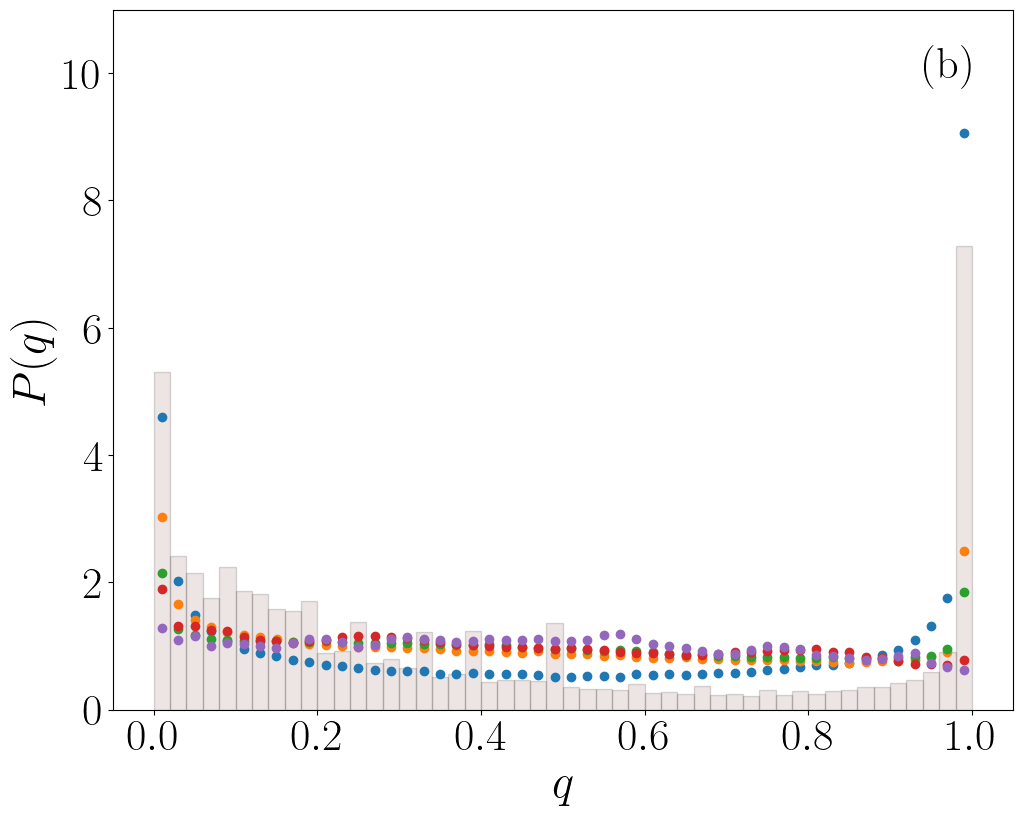

In [29]:
mpl.rcdefaults()
N=10
#* BIGGER SIZE
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = 'STIXGeneral'
plt.rc('font', size=N+22)          # controls default text sizes
plt.rc('axes', titlesize=N+24)     # fontsize of the axes title
plt.rc('axes', labelsize=N+24)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('ytick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('legend', fontsize=N+22)    # legend fontsize
plt.rc('figure', titlesize=N+24) 


keyword = "spending_fraction"
xlabel =r"$q$"
ylabel = r"$P(q)$"
disp = "comparison"
loglog = False
tag = query_to_tag(QUERY)
save_name = f"{disp}__metric={keyword}__filter={tag}"

text_x =  0.9
text_y = 0.95



# ---- load sarafu (bar base) ----
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))

# --------------------------------------------------
# FIXED AXES GEOMETRY (edit numbers if needed)
# --------------------------------------------------
ax_w, ax_h = 9, 7                 # axes size in inches
left, right = 1.5, 0.6         # margins in inches
bottom, top = 1.2, 0.6            # margins in inches

fig_w = ax_w + left + right
fig_h = ax_h + bottom + top

fig = plt.figure(figsize=(fig_w, fig_h))

divider = Divider(
    fig, (0, 0, 1, 1),
    horizontal=[
        Size.Fixed(left),
        Size.Fixed(ax_w),
        Size.Fixed(right),
    ],
    vertical=[
        Size.Fixed(bottom),
        Size.Fixed(ax_h),
        Size.Fixed(top),
    ],
)

ax = fig.add_axes(
    divider.get_position(),
    axes_locator=divider.new_locator(nx=1, ny=1)
)

# sarafu as bars (expects h1 = (centers, heights, widths))
ax.bar(h1[0], h1[1], h1[2], align="center", edgecolor="k", alpha=0.15, color="tab:brown", label='Sarafu')
# ax.plot(h1[0], h1[1], 'k--', marker=None,label='Sarafu')

# ---- overlay simulations (subset selected by QUERY) ----
for _, row in meta_slice.iterrows():
    s = row["s"]
    b = row["burstiness"]

    fname_simu = f"simulation__metric={keyword}__s={s}__b={b}"
    h_simu = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

    # simulation as line (expects h_simu = (x, y) or (centers, heights, ...))
    ax.plot(h_simu[0], h_simu[1], 'o', linestyle="None", label=rf"$\xi={s}$")

ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
if loglog:
    ax.loglog()
ax.text(text_x,text_y, "(b)", transform=ax.transAxes, va="top")
# ax.legend(fontsize = 26)
ax.set_ylim(0,11)

# optional save (encodes the filter used + metric)
# print(FIGURES / f"{disp}__metric={keyword}__filter={tag}.pdf")
fig.savefig(FIGURES / f"{save_name}.pdf")


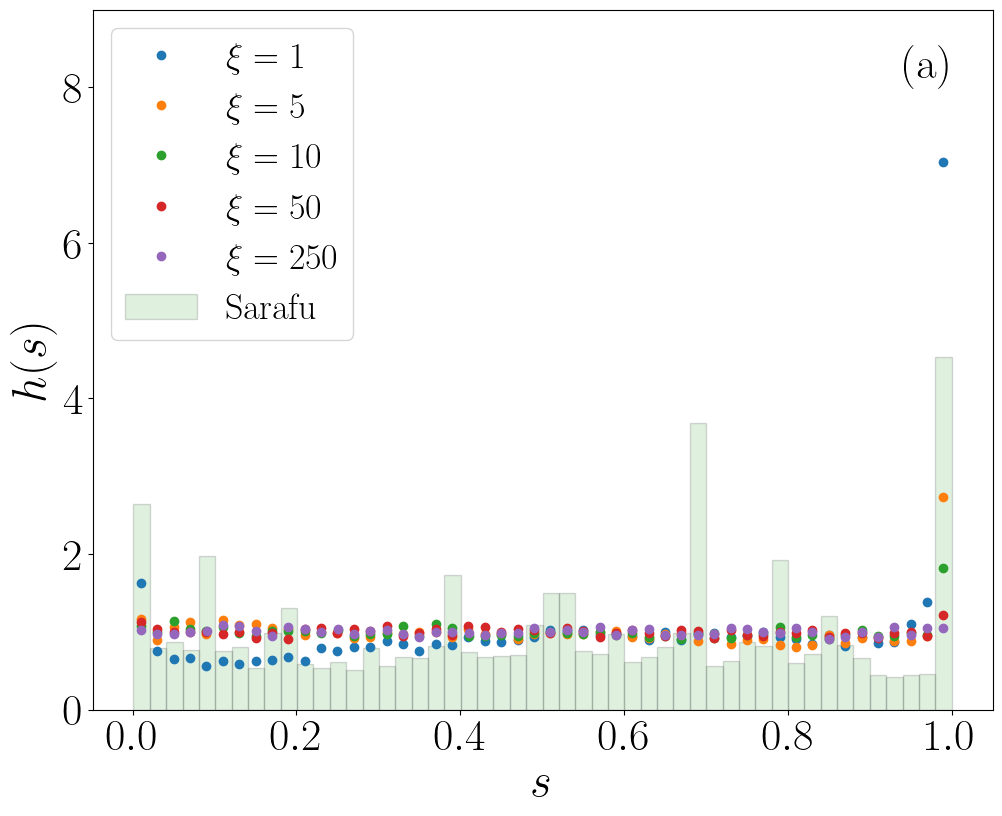

In [30]:
keyword = "spending_parameters"
xlabel = r"$s$"
ylabel = r"$h(s)$"
disp = "comparison"
loglog = False
tag = query_to_tag(QUERY)

# ---- load sarafu (bar base) ----
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))

# --------------------------------------------------
# FIXED AXES GEOMETRY (edit numbers if needed)
# --------------------------------------------------
ax_w, ax_h = 9, 7                 # axes size in inches
left, right = 1.5, 0.6         # margins in inches
bottom, top = 1.2, 0.6            # margins in inches


fig_w = ax_w + left + right
fig_h = ax_h + bottom + top

fig = plt.figure(figsize=(fig_w, fig_h))

divider = Divider(
    fig, (0, 0, 1, 1),
    horizontal=[
        Size.Fixed(left),
        Size.Fixed(ax_w),
        Size.Fixed(right),
    ],
    vertical=[
        Size.Fixed(bottom),
        Size.Fixed(ax_h),
        Size.Fixed(top),
    ],
)

ax = fig.add_axes(
    divider.get_position(),
    axes_locator=divider.new_locator(nx=1, ny=1)
)

# sarafu as bars (expects h1 = (centers, heights, widths))
ax.bar(h1[0], h1[1], h1[2], align="center", edgecolor="k", alpha=0.15, color="tab:green", label='Sarafu')
# ax.plot(h1[0], h1[1], 'k--', marker=None,label='Sarafu')

# ---- overlay simulations (subset selected by QUERY) ----
for _, row in meta_slice.iterrows():
    s = row["s"]
    b = row["burstiness"]

    fname_simu = f"simulation__metric={keyword}__s={s}__b={b}"
    h_simu = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

    # simulation as line (expects h_simu = (x, y) or (centers, heights, ...))
    ax.plot(h_simu[0], h_simu[1], 'o', linestyle="None", label=rf"$\xi={s}$")

ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
if loglog:
    ax.loglog()

ax.text(text_x,text_y, "(a)", transform=ax.transAxes, va="top")
ax.legend(fontsize = 26)
# ax.legend()
ax.set_ylim(0,9)

# optional save (encodes the filter used + metric)
# print(FIGURES / f"{disp}__metric={keyword}__filter={tag}.pdf")
fig.savefig(FIGURES / f"{disp}__metric={keyword}__filter={tag}.pdf")


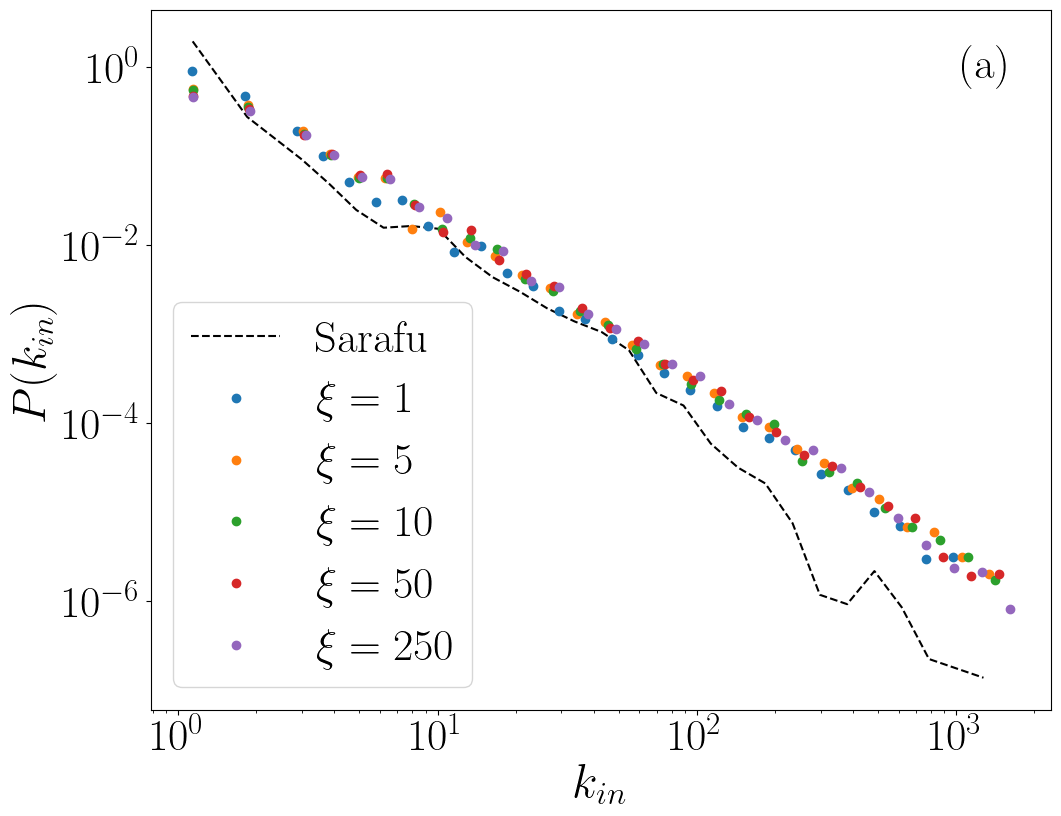

In [ ]:
mpl.rcdefaults()
N=10
#* BIGGER SIZE
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = 'STIXGeneral'
plt.rc('font', size=N+22)          # controls default text sizes
plt.rc('axes', titlesize=N+24)     # fontsize of the axes title
plt.rc('axes', labelsize=N+24)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('ytick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('legend', fontsize=N+22)    # legend fontsize
plt.rc('figure', titlesize=N+24) 

keyword = "in_degree"
xlabel = r"$k_{in}$"
ylabel = r"$P(k_{in})$"
disp = "overlap"
loglog = True
tag = query_to_tag(QUERY)
save_name = f"{disp}__metric={keyword}__filter={tag}"

text_x =  0.9
text_y = 0.95



# ---- load sarafu (bar base) ----
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))

# --------------------------------------------------
# FIXED AXES GEOMETRY (edit numbers if needed)
# --------------------------------------------------
ax_w, ax_h = 9, 7                 # axes size in inches
left, right = 1.5, 0.6         # margins in inches
bottom, top = 1.2, 0.6            # margins in inches

fig_w = ax_w + left + right
fig_h = ax_h + bottom + top

fig = plt.figure(figsize=(fig_w, fig_h))

divider = Divider(
    fig, (0, 0, 1, 1),
    horizontal=[
        Size.Fixed(left),
        Size.Fixed(ax_w),
        Size.Fixed(right),
    ],
    vertical=[
        Size.Fixed(bottom),
        Size.Fixed(ax_h),
        Size.Fixed(top),
    ],
)

ax = fig.add_axes(
    divider.get_position(),
    axes_locator=divider.new_locator(nx=1, ny=1)
)

# sarafu as bars (expects h1 = (centers, heights, widths))
# ax.bar(h1[0], h1[1], h1[2], align="center", edgecolor="k", alpha=0.15, color="tab:brown", label='Sarafu')
ax.plot(h1[0], h1[1], 'k--', marker=None,label='Sarafu')

# ---- overlay simulations (subset selected by QUERY) ----
for _, row in meta_slice.iterrows():
    s = row["s"]
    b = row["burstiness"]

    fname_simu = f"simulation__metric={keyword}__s={s}__b={b}"
    h_simu = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

    # simulation as line (expects h_simu = (x, y) or (centers, heights, ...))
    ax.plot(h_simu[0], h_simu[1], 'o', linestyle="None", label=rf"$\xi={s}$")

ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
if loglog:
    ax.loglog()
ax.text(text_x,text_y, "(a)", transform=ax.transAxes, va="top")
ax.legend(fontsize = 26)

# optional save (encodes the filter used + metric)
# print(FIGURES / f"{disp}__metric={keyword}__filter={tag}.pdf")
fig.savefig(FIGURES / f"{save_name}.pdf")


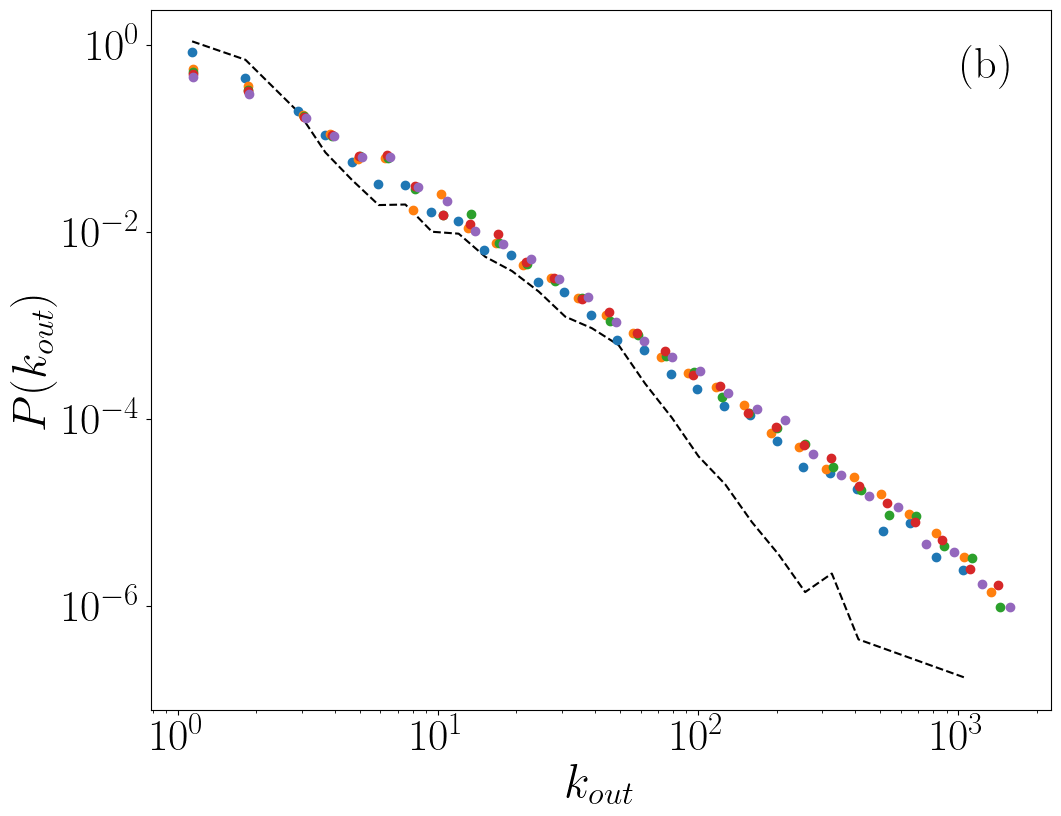

In [11]:
keyword = "out_degree"
xlabel = r"$k_{out}$"
ylabel = r"$P(k_{out})$"
disp = "overlap"
loglog = True
tag = query_to_tag(QUERY)

# ---- load sarafu (bar base) ----
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))

# --------------------------------------------------
# FIXED AXES GEOMETRY (edit numbers if needed)
# --------------------------------------------------
ax_w, ax_h = 9, 7                 # axes size in inches
left, right = 1.5, 0.6         # margins in inches
bottom, top = 1.2, 0.6            # margins in inches


fig_w = ax_w + left + right
fig_h = ax_h + bottom + top

fig = plt.figure(figsize=(fig_w, fig_h))

divider = Divider(
    fig, (0, 0, 1, 1),
    horizontal=[
        Size.Fixed(left),
        Size.Fixed(ax_w),
        Size.Fixed(right),
    ],
    vertical=[
        Size.Fixed(bottom),
        Size.Fixed(ax_h),
        Size.Fixed(top),
    ],
)

ax = fig.add_axes(
    divider.get_position(),
    axes_locator=divider.new_locator(nx=1, ny=1)
)

# sarafu as bars (expects h1 = (centers, heights, widths))
# ax.bar(h1[0], h1[1], h1[2], align="center", edgecolor="k", alpha=0.15, color="tab:brown", label='Sarafu')
ax.plot(h1[0], h1[1], 'k--', marker=None,label='Sarafu')

# ---- overlay simulations (subset selected by QUERY) ----
for _, row in meta_slice.iterrows():
    s = row["s"]
    b = row["burstiness"]

    fname_simu = f"simulation__metric={keyword}__s={s}__b={b}"
    h_simu = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

    # simulation as line (expects h_simu = (x, y) or (centers, heights, ...))
    ax.plot(h_simu[0], h_simu[1], 'o', linestyle="None", label=rf"$\xi={s}$")

ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
if loglog:
    ax.loglog()

# ax.legend()
ax.text(text_x,text_y, "(b)", transform=ax.transAxes, va="top")


# optional save (encodes the filter used + metric)
# print(FIGURES / f"{disp}__metric={keyword}__filter={tag}.pdf")
fig.savefig(FIGURES / f"{disp}__metric={keyword}__filter={tag}.pdf")


In [60]:
mpl.rcdefaults()
N=0
#* BIGGER SIZE
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = 'STIXGeneral'
plt.rc('font', size=N+22)          # controls default text sizes
plt.rc('axes', titlesize=N+24)     # fontsize of the axes title
plt.rc('axes', labelsize=N+24)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('ytick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('legend', fontsize=N+22)    # legend fontsize
plt.rc('figure', titlesize=N+24) 

metric = f"inter_event_times"
spec1 = 'individual'
spec2 = 'global'
fname1 = f"sarafu__metric={metric}_{spec1}__s=NA__b=NA.pkl"
fname2 = f"sarafu__metric={metric}_{spec2}__s=NA__b=NA.pkl"

hs = pickle.load(open(SARAFU_PICKLED / "histograms" / fname1, "rb"))
h0 = pickle.load(open(SARAFU_PICKLED / "histograms" / fname2, "rb"))

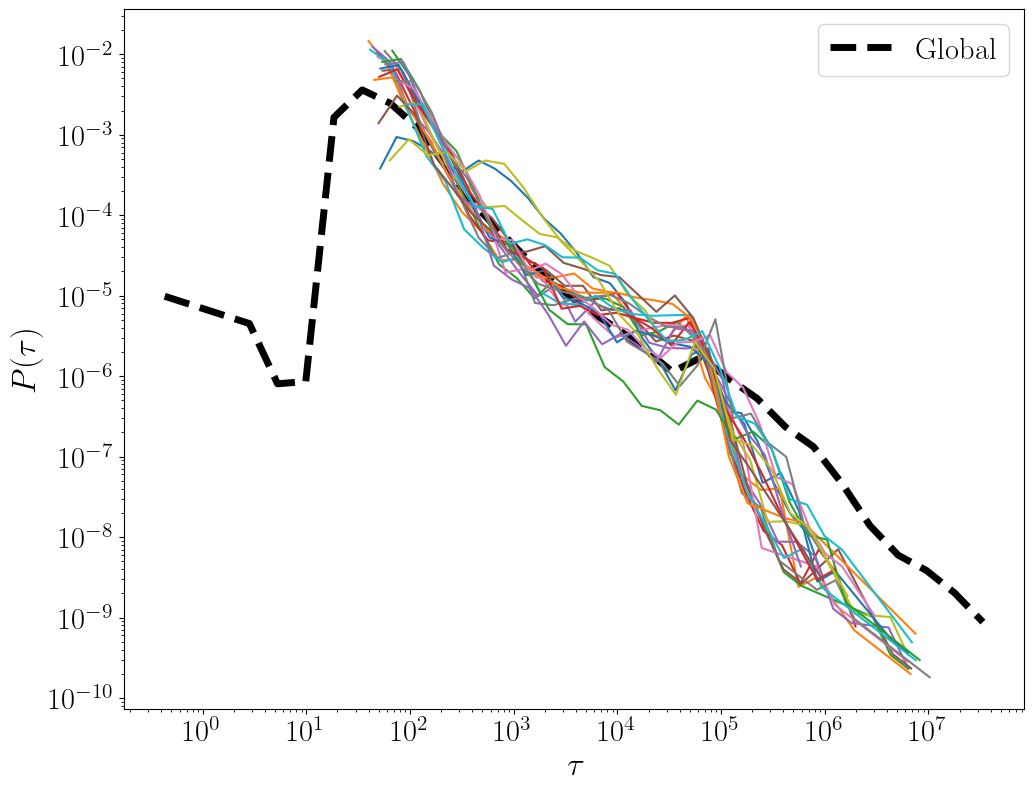

In [ ]:
# R,C = 1,1
# W = 9
# H = 7


# fig, ax = plt.subplots(R,C, figsize=(W*C,H*R), sharex=False)


# keyword = "inter-event_times"
# disp = 'single'
# tag = "sarafu-global-vs-single"
# x_text = 0.9
# y_text = 0.95

# ax.plot(h0[0], h0[1], "--", color="k",lw = 5)


# most_active_sarafu = sarafu['agents'].nlargest(50, columns = 'tx_out')[['crid','tx_out']]

# for k in most_active_sarafu.head(20).crid:
#     h = hs[k]
#     ax.plot(h[0],h[1])

# ax.set_ylabel(r"$h(\tau)$")
# ax.set_xlabel(r"$\tau$")

# legend_elements = [
#     Line2D([0], [0], linestyle="--", color="black", label="Global"),
#     # Line2D([0], [0], linestyle="-", marker=None, color="black",
#         #    label="Individuals"),
#     # Line2D([0], [0], linestyle="-", color="C0", label="Final Balances"),
#     # Line2D([0], [0], linestyle="-", color="C1", label="Transaction Sizes"),
# ]
# ax.legend(handles=legend_elements)
# ax.loglog()
# # ax.text(x_text, y_text, "(a)", transform=ax.transAxes, va="top")

# # fig.tight_layout()


In [ ]:
# fig.savefig(
#     FIGURES / f"{disp}__metrics={keyword}__filter={tag}.pdf"
# # )

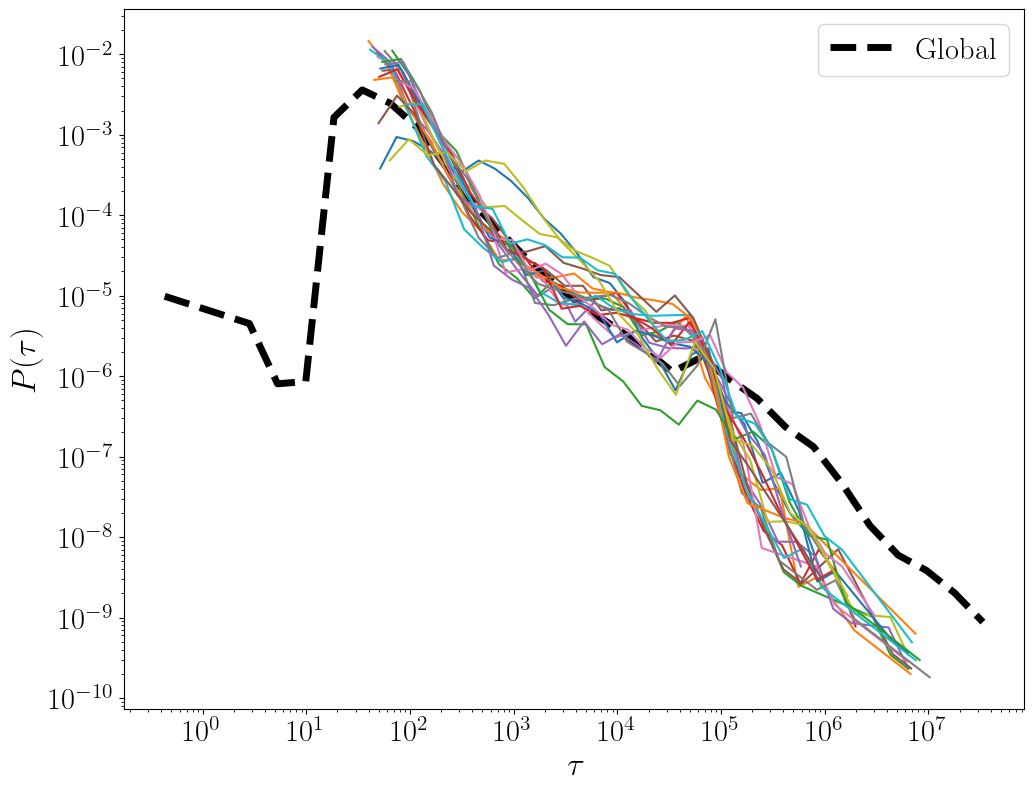